In [111]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("day12datasetclean.csv", encoding="latin1")


df["Sales"] = (df["Sales"].astype(str).str.replace(r"[^0-9.]", "", regex=True))
df["Profit"] = (df["Profit"].astype(str).str.replace(r"[^\d.-]", "", regex=True))


df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Profit"] = df["Profit"].fillna(df["Profit"].mean())


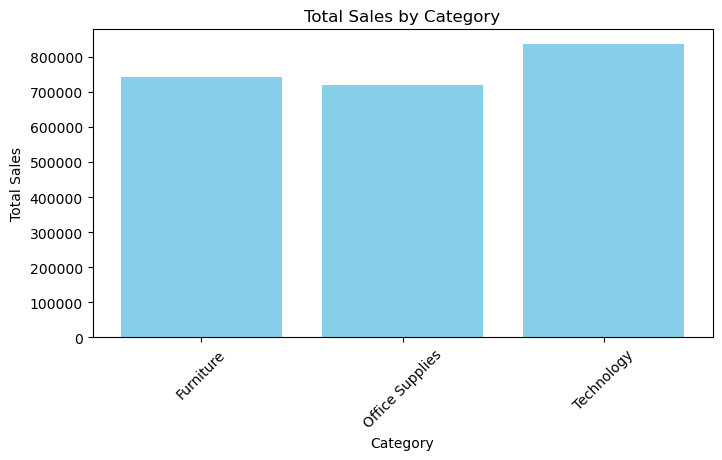

In [112]:
category_sales = df.groupby("Category")["Sales"].sum().head()

plt.figure(figsize=(8,4))
plt.bar(category_sales.index, category_sales.values, color="skyblue")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

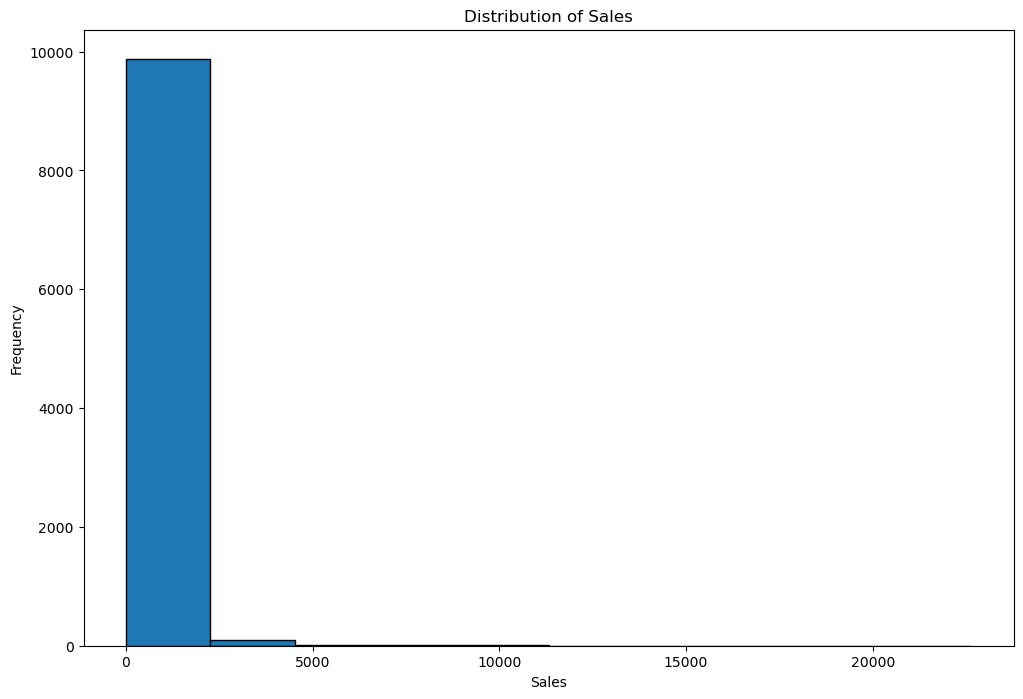

In [113]:
plt.figure(figsize=(12,8))
plt.hist(df['Sales'], bins=10, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

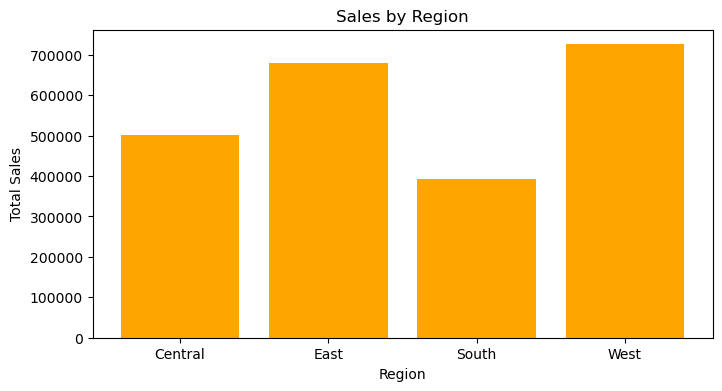

In [114]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,4))
plt.bar(region_sales.index, region_sales.values, color="orange")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


/tmp/ipykernel_2448/2240548018.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"]).dt.month


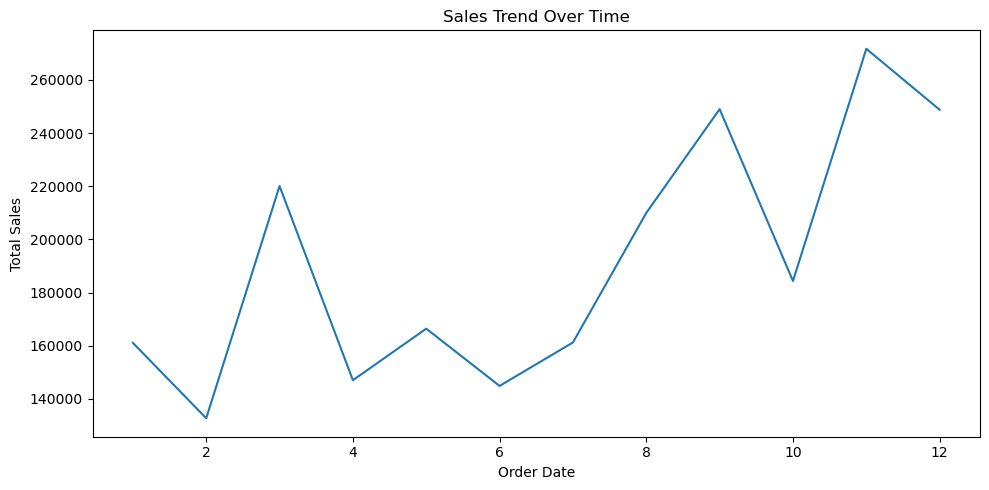

In [115]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"]).dt.month

# Group by date and sum sales
sales_trend = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(10,5))

plt.plot(sales_trend.index, sales_trend.values)

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()